# 📊 คำอธิบายและตัวอย่างการปฏิบัติการการถดถอยพหุนาม (Polynomial Regression)

ยินดีต้อนรับสู่โน้ตบุ๊กประกอบการอธิบายเรื่อง **การถดถอยพหุนาม (Polynomial Regression)**! ในโน้ตบุ๊กนี้เราจะ:
1. สร้างชุดข้อมูลจำลองแบบโค้ง (ความสัมพันธ์แบบไม่เป็นเชิงเส้น) ร่วมกับสัญญาณรบกวน (Noise)
2. ทดลองสร้างแบบจำลอง **Linear Regression** แบบเส้นตรงปกติเพื่อแสดงว่าทำไมแบบจำลองจึงเกิดการอันเดอร์ฟิต (Underfitting) กับข้อมูล
3. ทำการแปลงคุณลักษณะด้วยพหุนาม (Polynomial Feature Transformation) เพื่อฟิตเส้นโค้ง
4. เปรียบเทียบแบบจำลองที่มีระดับดีกรีต่างกัน (อันเดอร์ฟิต, ฟิตได้ดีเยี่ยม, และโอเวอร์ฟิต)
5. ลงมือพัฒนาการขยายคุณลักษณะด้วยพหุนามและคำนวณหาค่าน้ำหนักจากศูนย์ (from scratch) โดยใช้ **สมการปกติ (Normal Equation)**:
   $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

เริ่มต้นด้วยการนำเข้าไลบรารีที่จำเป็นกันก่อนครับ

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# กำหนดค่า seed เพื่อให้ได้ผลลัพธ์การสุ่มเหมือนเดิมทุกครั้ง
np.random.seed(42)

## 1. การสร้างข้อมูลจำลอง (Data Generation)

เราจะสร้างข้อมูลจำลองขึ้นมาโดยใช้สมการกำลังสอง (Quadratic Equation):
$$y = 0.5x^2 - 2.0x + 3.0 + \epsilon$$

โดยกำหนดให้:
*   True quadratic weight ($w_2$) = 0.5
*   True linear weight ($w_1$) = -2.0
*   True bias ($w_0$) = 3.0
*   $\epsilon$ คือสัญญาณรบกวนแบบเกาส์เซียน (Gaussian Noise)

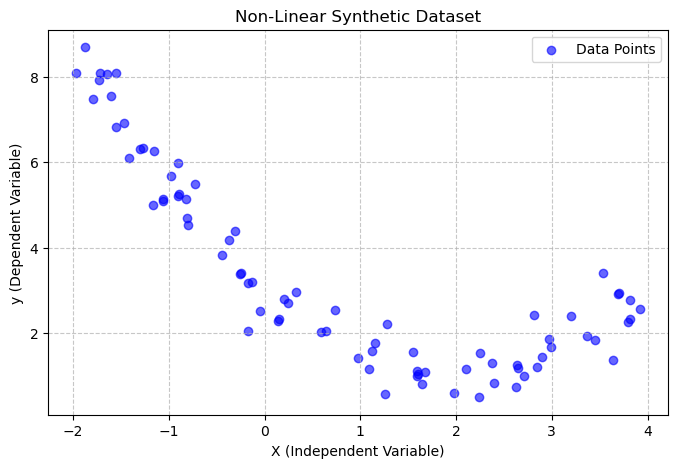

In [2]:
# สุ่มสร้างจุดข้อมูล 80 จุดที่มีค่าระหว่าง -2 ถึง 4
X = np.random.rand(80, 1) * 6 - 2
y = 0.5 * (X**2) - 2.0 * X + 3.0 + np.random.randn(80, 1) * 0.5

# เรียงลำดับ X และ y เพื่อให้การพล็อตกราฟเส้นตรงมีความราบเรียบไม่มีเส้นไขว้กัน
sort_idx = np.argsort(X.flatten())
X_sorted = X[sort_idx]
y_sorted = y[sort_idx]

# พล็อตกราฟแสดงจุดข้อมูลที่ถูกสร้างขึ้น
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Points')
plt.xlabel('X (Independent Variable)')
plt.ylabel('y (Dependent Variable)')
plt.title('Non-Linear Synthetic Dataset')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 2. เส้นถดถอยเชิงเส้นเทียบกับพหุนาม (ผลต่างระหว่างอคติและความแปรปรวน - Bias-Variance Tradeoff)

หากเราพยายามฟิตข้อมูลนี้ด้วยเส้นตรง (ดีกรี 1) แบบจำลองจะไม่สามารถเก็บลักษณะความโค้งของแนวโน้มข้อมูลได้ (เกิดปัญหาอคติสูง หรือ Underfitting)
แต่หากเราพยายามฟิตด้วยพหุนามที่มีดีกรีสูงมากๆ (เช่น ดีกรี 15) แบบจำลองจะเข้ากับจุดสัญญาณรบกวนมากเกินไป (เกิดปัญหาความแปรปรวนสูง หรือ Overfitting)
เราลองมาดูกราฟเปรียบเทียบการพล็อตเส้นพหุนามดีกรี 1, 2 และ 15 กันครับ

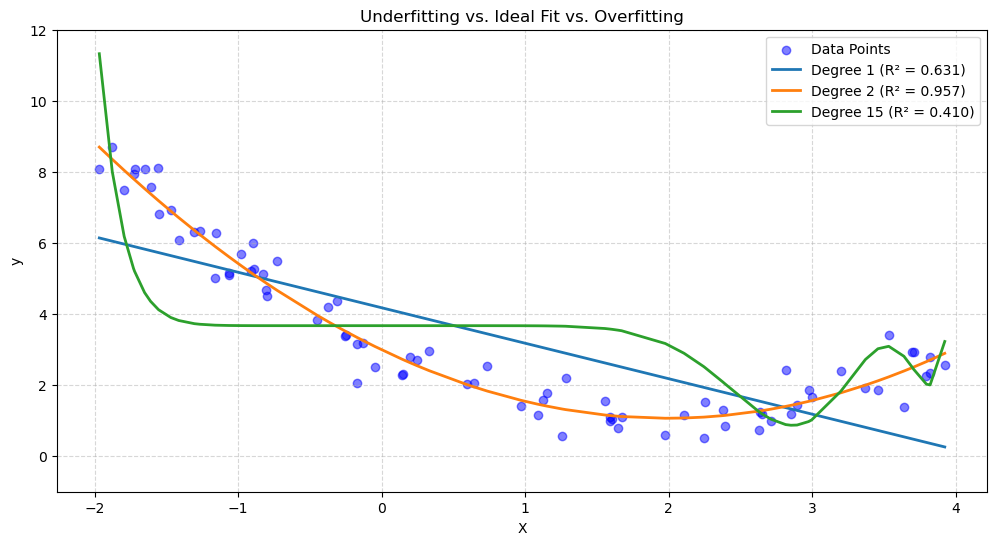

In [3]:
degrees = [1, 2, 15]
plt.figure(figsize=(12, 6))
plt.scatter(X, y, color='blue', alpha=0.5, label='Data Points')

for degree in degrees:
    # 1. แปลงค่า X เป็นคุณลักษณะแบบพหุนาม (Polynomial Features)
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)
    
    # 2. เทรนแบบจำลอง Linear Regression บนคุณลักษณะพหุนามที่ถูกแปลงมาแล้ว
    model = LinearRegression()
    model.fit(X_poly, y)
    
    # 3. ทำนายผลบน X_sorted เพื่อใช้วาดกราฟเส้นถดถอย
    X_poly_sorted = poly_features.transform(X_sorted)
    y_pred = model.predict(X_poly_sorted)
    
    # คำนวณค่า R2 Score
    r2 = r2_score(y, model.predict(X_poly))
    
    plt.plot(X_sorted, y_pred, label=f'Degree {degree} (R² = {r2:.3f})', linewidth=2)

plt.xlabel('X')
plt.ylabel('y')
plt.title('Underfitting vs. Ideal Fit vs. Overfitting')
plt.ylim(-1, 12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 3. การสร้าง Polynomial Regression จากศูนย์ด้วยสมการปกติ (Normal Equation from Scratch)

สำหรับการถดถอยเชิงเส้นหลายตัวแปรหรือการถดถอยพหุนาม เราสามารถวิเคราะห์หาพารามิเตอร์น้ำหนักที่เหมาะสมที่สุดผ่านกระบวนการทางคณิตศาสตร์ได้โดยตรงด้วย **สมการปกติ (Normal Equation)**:
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

โดยกำหนดให้:
*   $\mathbf{X}$ คือเมทริกซ์คุณลักษณะ โดยแต่ละแถวอยู่ในรูปแบบ $[1, x, x^2, \dots, x^n]$
*   $\mathbf{y}$ คือเวกเตอร์ของเป้าหมายจริง (Target Vector)
*   $\mathbf{w}$ คือเวกเตอร์ของน้ำหนักพารามิเตอร์ $[w_0, w_1, w_2, \dots, w_n]^T$

เรามาเขียนการคำนวณคุณลักษณะพหุนามและการหาคำตอบนี้ด้วยไลบรารี NumPy ล้วน ๆ กันครับ

In [4]:
def get_polynomial_features(X, degree):
    """
    สร้างคุณลักษณะแบบพหุนามด้วยตัวเอง รวมไปถึงเทอมอคติ (คอลัมน์เลข 1)
    """
    m = len(X)
    # สร้างคอลัมน์ของเลข 1 สำหรับเทอมอคติ (Bias Intercept)
    X_poly = np.ones((m, 1))
    
    # เพิ่มเลขยกกำลังของ X เข้าไปทีละขั้น
    for power in range(1, degree + 1):
        X_poly = np.hstack((X_poly, X ** power))
        
    return X_poly

def solve_normal_equation(X, y):
    """
    หาค่า w โดยใช้สมการปกติ: w = (X^T * X)^-1 * X^T * y
    """
    XTX = X.T @ X
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv @ X.T @ y
    return w

# 1. แปลงคุณลักษณะให้เป็นดีกรี 2 (สมการกำลังสอง)
X_poly_scratch = get_polynomial_features(X, degree=2)

# 2. หาคำตอบโดยใช้สมการปกติ (Normal Equation)
weights_scratch = solve_normal_equation(X_poly_scratch, y)

print("Learned Polynomial Coefficients (Scratch):")
for i, w in enumerate(weights_scratch.flatten()):
    print(f"w_{i} (coefficient for X^{i}): {w:.4f}")

# เปรียบเทียบกับค่าสัมประสิทธิ์จริงที่ตั้งต้นไว้ (0.5x^2 - 2x + 3)
print(f"\nTrue Coefficients: w_0 = 3.0, w_1 = -2.0, w_2 = 0.5")

Learned Polynomial Coefficients (Scratch):
w_0 (coefficient for X^0): 2.9942
w_1 (coefficient for X^1): -1.9397
w_2 (coefficient for X^2): 0.4881

True Coefficients: w_0 = 3.0, w_1 = -2.0, w_2 = 0.5


## 4. การประเมินผลประสิทธิภาพแบบจำลอง (Model Evaluation)

ลองนำค่าน้ำหนักที่เราคำนวณได้เองจากสูตรสมการปกติมาทำนายผลข้อมูล และตรวจสอบความแม่นยำด้วยค่า Mean Squared Error (MSE) และ R-squared ($R^2$)

In [ ]:
# ทำนายผลด้วยน้ำหนักที่ได้จากสมการปกติ
X_poly_sorted_scratch = get_polynomial_features(X_sorted, degree=2)
y_pred_scratch = X_poly_sorted_scratch @ weights_scratch

# คำนวณหาตัวชี้วัดความถูกต้องโดยรวม
y_pred_all_scratch = X_poly_scratch @ weights_scratch
mse_scratch = mean_squared_error(y, y_pred_all_scratch)
r2_scratch = r2_score(y, y_pred_all_scratch)

print(f"Scratch Model (Degree 2) MSE: {mse_scratch:.4f}")
print(f"Scratch Model (Degree 2) R2 Score: {r2_scratch:.4f}")

# พล็อตกราฟแสดงเส้นพหุนามที่เราเขียนขึ้นมาเอง
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', alpha=0.6, label='Data Points')
plt.plot(X_sorted, y_pred_scratch, color='red', linewidth=2.5, label='Custom Polynomial Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Custom Polynomial Regression Fit (Normal Equation)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 💡 ความเชื่อมโยงสู่ Computer Vision และ YOLO
*   **เส้นวิถีของตำแหน่งวัตถุในระบบติดตาม (Object Tracking Trajectories):** ตัวติดตามวัตถุอย่าง DeepSORT หรือ ByteTrack จะต้องระบุตำแหน่งของกล่องวัตถุในแต่ละเฟรมเมื่อเวลาผ่านไป ซึ่งพิกัดพิกเซลของกล่อง Bounding Box ได้แก่ $x(t)$ และ $y(t)$ มักเคลื่อนไหวเป็นเส้นโค้งมากกว่าแนวเส้นตรง การประยุกต์ใช้การถดถอยพหุนามดีกรีสองหรือดีกรีสามมาพยากรณ์วิถีล่วงหน้า ช่วยให้ระบบติดตามทำนายพิกัดตำแหน่งกล่องวัตถุในอนาคตได้อย่างแม่นยำสูง แม้ว่าวัตถุจะถูกบังชั่วขณะ (Occlusions) ก็ตาม